### CONFIGURATION AND LOADING

In [10]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Layer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

PROCESSED_PATH = r'../../processed_data'
MODEL_SAVE_PATH = r'./model_checkpoints'

if not os.path.exists(MODEL_SAVE_PATH):
    os.makedirs(MODEL_SAVE_PATH)

print("Loading FD003 Global Data...")
X_train = np.load(os.path.join(PROCESSED_PATH, 'X_train_FD003.npy'))
y_train = np.load(os.path.join(PROCESSED_PATH, 'y_train_FD003.npy'))
X_test = np.load(os.path.join(PROCESSED_PATH, 'X_test_FD003.npy'))
y_test = np.load(os.path.join(PROCESSED_PATH, 'y_test_FD003.npy'))

print(f"X_train Shape: {X_train.shape}")

Loading FD003 Global Data...
X_train Shape: (21720, 30, 20)


### Attention Layer 

In [11]:
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1), initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1), initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)
    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

### STANDARD ATTENTION MODEL

In [14]:
def build_model(input_shape):
    inputs = Input(shape=input_shape)
    
    x = LSTM(128, return_sequences=True, name='lstm_layer')(inputs)
    x = Dropout(0.3)(x)
    
    x = Attention(name='attention_layer')(x)
    
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    
    outputs = Dense(1, activation='linear')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

model = build_model((X_train.shape[1], X_train.shape[2]))
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 30, 20)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_layer (LSTM)                    │ (None, 30, 128)             │          76,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 30, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer (Attention)          │ (None, 128)                 │             158 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 86,815 (339.12 KB)

 Trainable params: 86,815 (339.12 KB)

 Non-trainable params: 0 (0.00 B)

### TRAINING 

In [16]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=False)

print("Starting FD003 Global Training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=80, 
    batch_size=200, 
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Starting FD003 Global Training...
Epoch 1/80
109/109 ━━━━━━━━━━━━━━━━━━━━ 29s 196ms/step - loss: 6134.3550 - mae: 66.9449 - val_loss: 1805.0587 - val_mae: 36.1710 - learning_rate: 0.0010
Epoch 2/80
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 184ms/step - loss: 1774.5837 - mae: 36.8389 - val_loss: 1549.8960 - val_mae: 33.7139 - learning_rate: 0.0010
Epoch 3/80
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 189ms/step - loss: 1212.3921 - mae: 29.4282 - val_loss: 672.8762 - val_mae: 19.4121 - learning_rate: 0.0010
Epoch 4/80
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 186ms/step - loss: 724.4666 - mae: 20.9469 - val_loss: 1174.6389 - val_mae: 27.6111 - learning_rate: 0.0010
Epoch 5/80
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 181ms/step - loss: 621.0052 - mae: 19.3268 - val_loss: 577.1763 - val_mae: 18.2723 - learning_rate: 0.0010
Epoch 6/80
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 184ms/step - loss: 505.1111 - mae: 17.3821 - val_loss: 576.6910 - val_mae: 17.9910 - learning_rate: 0.0010
Epoch 7/80
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 181ms/step

### EVALUATION

In [17]:
print("\nResults: ")
predictions = model.predict(X_test)
rmse = np.sqrt(np.mean((predictions.flatten() - y_test) ** 2))
print(f"Final Test RMSE: {rmse:.4f}")

# Save
model.save(os.path.join(MODEL_SAVE_PATH, 'attention_lstm_fd003_global.h5'))


Results: 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


Final Test RMSE: 21.0448


### VISUALISING

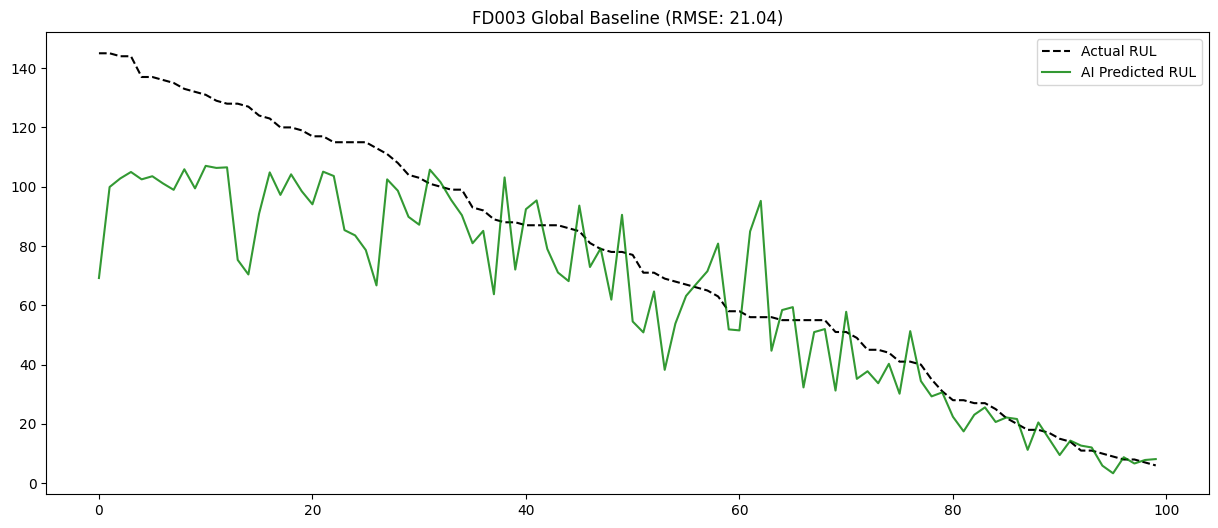

In [18]:
results_df = pd.DataFrame({'True': y_test, 'Pred': predictions.flatten()}).sort_values('True', ascending=False).reset_index(drop=True)
plt.figure(figsize=(15, 6))
plt.plot(results_df['True'], label='Actual RUL', color='black', linestyle='--')
plt.plot(results_df['Pred'], label='AI Predicted RUL', color='green', alpha=0.8)
plt.title(f'FD003 Global Baseline (RMSE: {rmse:.2f})')
plt.legend()
plt.show()